In [16]:
!pip install nltk


In [17]:
import nltk
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
from google.colab import files
uploaded = files.upload()

Saving train_data.txt to train_data (1).txt


In [19]:
df = pd.read_csv("train_data.txt",
    sep=":::",
    names=["Movie_name", "Genre", "Description"],
    engine="python"
)


In [20]:
df.head(5)
df.describe()


,Movie_name,Genre,Description
count,54214,54214,54214
unique,54214,27,54086
top,Nature's Fury: Storm of the Century (2006),drama,Grammy - music award of the American academy ...
freq,1,13613,12


In [21]:
print(df.columns)


Index(['Movie_name', 'Genre', 'Description'], dtype='object')


In [22]:
df['Genre'].unique()

array([' drama ', ' thriller ', ' adult ', ' documentary ', ' comedy ',
       ' crime ', ' reality-tv ', ' horror ', ' sport ', ' animation ',
       ' action ', ' fantasy ', ' short ', ' sci-fi ', ' music ',
       ' adventure ', ' talk-show ', ' western ', ' family ', ' mystery ',
       ' history ', ' news ', ' biography ', ' romance ', ' game-show ',
       ' musical ', ' war '], dtype=object)

In [23]:
df['Genre'].value_counts()

,count
Genre,
drama,13613
documentary,13096
comedy,7447
short,5073
horror,2204
thriller,1591
action,1315
western,1032
reality-tv,884


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54214 entries, 1 to 54214
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Movie_name   54214 non-null  object
 1   Genre        54214 non-null  object
 2   Description  54214 non-null  object
dtypes: object(3)
memory usage: 1.7+ MB


In [25]:
df=df[:14000]

In [26]:
df['Genre'].isnull().sum(),df['Description'].isnull().sum()

(np.int64(0), np.int64(0))

([<matplotlib.patches.Wedge at 0x7f5bbc9fd9d0>,
 [Text(0.7783408731955718, 0.7772936929585593, ' drama '),
  Text(-0.7578464077547891, 0.7972884184867871, ' thriller '),
  Text(-1.019912433085333, -0.41204202314564514, ' adult '),
  Text(-0.4876980014718093, -0.985977007521171, ' documentary '),
  Text(-0.04762522819280862, -1.0989685335074808, ' comedy '),
  Text(0.19106669176357727, -1.0832790588294976, ' crime '),
  Text(0.3714499095378242, -1.0353863842567868, ' reality-tv '),
  Text(0.509260757544074, -0.9750146054422139, ' horror '),
  Text(0.6166571819126249, -0.9108973158350947, ' sport '),
  Text(0.7028767825920313, -0.8461466944289711, ' animation '),
  Text(0.7797347141382024, -0.7758954669076343, ' action '),
  Text(0.8464621239038461, -0.7024968845455403, ' fantasy '),
  Text(0.9006737455094288, -0.6314956881483964, ' short '),
  Text(0.9456835188780103, -0.561856460426063, ' sci-fi '),
  Text(0.9843296826695614, -0.49101433361526275, ' music '),
  Text(1.0147494817110592,

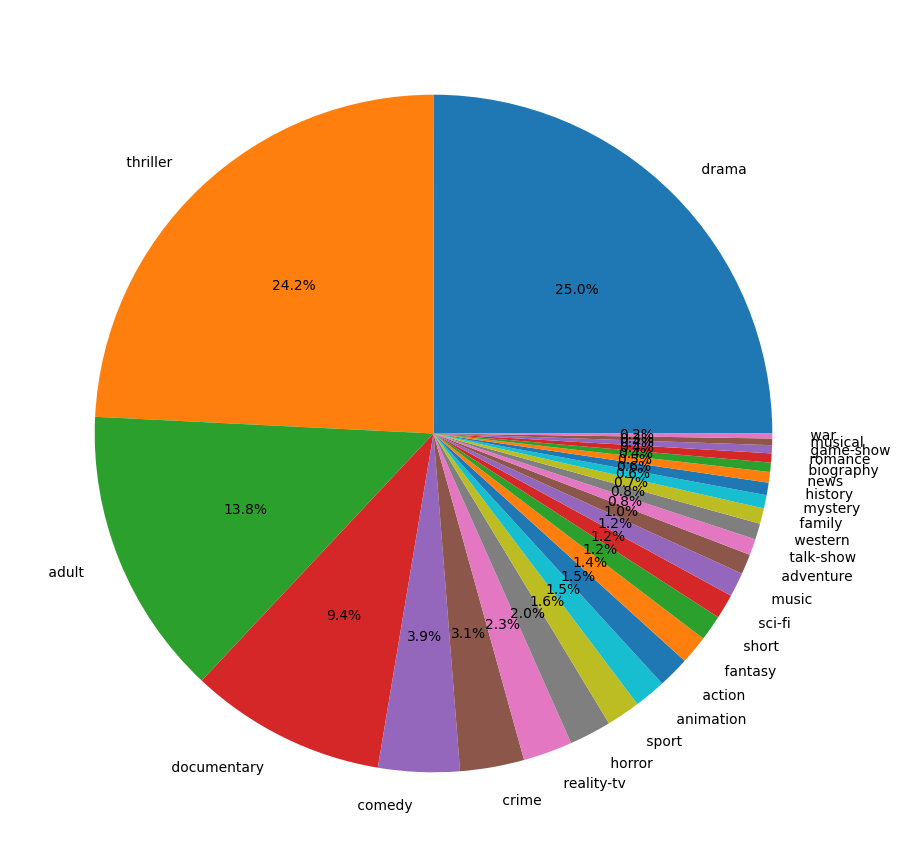

In [28]:
plt.figure(figsize=(11,11))
plt.pie(df['Genre'].value_counts(),labels=[' drama ', ' thriller ', ' adult ', ' documentary ', ' comedy ',
       ' crime ', ' reality-tv ', ' horror ', ' sport ', ' animation ',
       ' action ', ' fantasy ', ' short ', ' sci-fi ', ' music ',
       ' adventure ', ' talk-show ', ' western ', ' family ', ' mystery ',
       ' history ', ' news ', ' biography ', ' romance ', ' game-show ',
       ' musical ', ' war '],autopct='%0.1f%%')

In [29]:
df.tail()

,Movie_name,Genre,Description
13996,Bridging the Gap: A Middle East Comedy Confer...,comedy,"Hosted by Ahmed Ahmed and Avi Liberman, ""Brid..."
13997,Nieuw tiengemeten (2010),documentary,New Tiengemeten is the account of the transfo...
13998,That's What She Told Me (2011),short,A New York Artist accidentally summons the Gh...
13999,All Things Bakelite: The Age of Plastic (2016),documentary,"All Things Bakelite, a film by John Maher, is..."
14000,Hanna D. - La ragazza del Vondel Park (1984),drama,Hanna is a girl completely abandoned to herse...


In [30]:
def remove_punct(text):
    import string as st
    punct=st.punctuation
    new_text=''.join([char for char in text if char not in punct])
    return new_text

df['Description']=df['Description'].apply(lambda x:remove_punct(x))

In [31]:
df.tail()

,Movie_name,Genre,Description
13996,Bridging the Gap: A Middle East Comedy Confer...,comedy,Hosted by Ahmed Ahmed and Avi Liberman Bridgi...
13997,Nieuw tiengemeten (2010),documentary,New Tiengemeten is the account of the transfo...
13998,That's What She Told Me (2011),short,A New York Artist accidentally summons the Gh...
13999,All Things Bakelite: The Age of Plastic (2016),documentary,All Things Bakelite a film by John Maher is a...
14000,Hanna D. - La ragazza del Vondel Park (1984),drama,Hanna is a girl completely abandoned to herse...


In [32]:
df['Description']=df['Description'].apply(lambda x:x.lower())
df.head()

,Movie_name,Genre,Description
1,Oscar et la dame rose (2009),drama,listening in to a conversation between his do...
2,Cupid (1997),thriller,a brother and sister with a past incestuous r...
3,"Young, Wild and Wonderful (1980)",adult,as the bus empties the students for their fie...
4,The Secret Sin (1915),drama,to help their unemployed father make ends mee...
5,The Unrecovered (2007),drama,the films title refers not only to the unreco...


In [33]:
from nltk.tokenize import TreebankWordTokenizer

tokenizer = TreebankWordTokenizer()

def toknize(text):
    if isinstance(text, list):  # if already tokenized
        return text
    elif isinstance(text, str):  # if it's a string, tokenize it
        return tokenizer.tokenize(text)
    else:
        return []  # fallback for None or other types

df['Description'] = df['Description'].fillna("").apply(toknize)


In [34]:
df.head(5)

,Movie_name,Genre,Description
1,Oscar et la dame rose (2009),drama,"[listening, in, to, a, conversation, between, ..."
2,Cupid (1997),thriller,"[a, brother, and, sister, with, a, past, inces..."
3,"Young, Wild and Wonderful (1980)",adult,"[as, the, bus, empties, the, students, for, th..."
4,The Secret Sin (1915),drama,"[to, help, their, unemployed, father, make, en..."
5,The Unrecovered (2007),drama,"[the, films, title, refers, not, only, to, the..."


In [35]:
def stemming(text):
    from nltk import PorterStemmer
    ps=PorterStemmer().stem
    # dir(PorterStemmer())
    new_text=" ".join([ps(word) for word in text ])
    return new_text
df['Description']=df['Description'].apply(lambda x : stemming(x))

In [36]:
df.head(5)

,Movie_name,Genre,Description
1,Oscar et la dame rose (2009),drama,listen in to a convers between hi doctor and p...
2,Cupid (1997),thriller,a brother and sister with a past incestu relat...
3,"Young, Wild and Wonderful (1980)",adult,as the bu empti the student for their field tr...
4,The Secret Sin (1915),drama,to help their unemploy father make end meet ed...
5,The Unrecovered (2007),drama,the film titl refer not onli to the unrecov bo...


In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer

tf_idf=TfidfVectorizer()

Description_tf_idf=tf_idf.fit_transform(df['Description'])

print(Description_tf_idf.shape)

Description_tf_idf=pd.DataFrame(Description_tf_idf.toarray())
Description_tf_idf.columns = tf_idf.get_feature_names_out()

Description_tf_idf

(14000, 50500)


,00,000,000km,003,007,01,02,03,04,040404,...,ťcoquetti,ťel,ťgoe,ťkleineť,ťrare,ťthe,ťŕ,żestán,żo,żte
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [38]:
df['Description len']=df['Description'].apply(lambda x:len(x)-x.count(' '))
df.head(10)

,Movie_name,Genre,Description,Description len
1,Oscar et la dame rose (2009),drama,listen in to a convers between hi doctor and p...,390
2,Cupid (1997),thriller,a brother and sister with a past incestu relat...,142
3,"Young, Wild and Wonderful (1980)",adult,as the bu empti the student for their field tr...,457
4,The Secret Sin (1915),drama,to help their unemploy father make end meet ed...,794
5,The Unrecovered (2007),drama,the film titl refer not onli to the unrecov bo...,451
6,Quality Control (2011),documentary,qualiti control consist of a seri of 16mm sing...,1149
7,"""Pink Slip"" (2009)",comedy,in tough econom time max and joey have all but...,240
8,One Step Away (1985),crime,ron petri keanu reev is a troubl teen whose li...,225
9,"""Desperate Hours"" (2016)",reality-tv,a sudden calamit event caus great loss of life...,328
10,Spirits (2014/I),horror,four high school student embark on a terrifi j...,322


In [39]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
df['Description_len_sclr'] = scaler.fit_transform(df['Description len'].values.reshape(-1, 1))
df.head(5)

,Movie_name,Genre,Description,Description len,Description_len_sclr
1,Oscar et la dame rose (2009),drama,listen in to a convers between hi doctor and p...,390,0.047919
2,Cupid (1997),thriller,a brother and sister with a past incestu relat...,142,0.014631
3,"Young, Wild and Wonderful (1980)",adult,as the bu empti the student for their field tr...,457,0.056913
4,The Secret Sin (1915),drama,to help their unemploy father make end meet ed...,794,0.102148
5,The Unrecovered (2007),drama,the film titl refer not onli to the unrecov bo...,451,0.056107


In [40]:
target=df['Genre']
feature=df.drop(['Genre','Movie_name','Description','Description len'],axis=1)
target.head(5)

,Genre
1,drama
2,thriller
3,adult
4,drama
5,drama


In [41]:
target

,Genre
1,drama
2,thriller
3,adult
4,drama
5,drama
...,...
13996,comedy
13997,documentary
13998,short
13999,documentary


In [42]:
feature

,Description_len_sclr
1,0.047919
2,0.014631
3,0.056913
4,0.102148
5,0.056107
...,...
13996,0.024698
13997,0.044564
13998,0.074362
13999,0.041477


In [43]:
target.shape , feature.shape

((14000,), (14000, 1))

In [44]:
Description_tf_idf.head()

,00,000,000km,003,007,01,02,03,04,040404,...,ťcoquetti,ťel,ťgoe,ťkleineť,ťrare,ťthe,ťŕ,żestán,żo,żte
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [45]:
print(feature.shape)
print(Description_tf_idf.shape)

(14000, 1)
(14000, 50500)


In [46]:
feature.reset_index(drop=True, inplace=True)
Description_tf_idf.reset_index(drop=True, inplace=True)
feature = pd.concat([feature, pd.DataFrame(Description_tf_idf)], axis=1)

In [47]:
feature.shape

(14000, 50501)

In [48]:
feature.head()

,Description_len_sclr,00,000,000km,003,007,01,02,03,04,...,ťcoquetti,ťel,ťgoe,ťkleineť,ťrare,ťthe,ťŕ,żestán,żo,żte
0,0.047919,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.014631,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.056913,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.102148,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.056107,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Suppose your DataFrame is named df
# And you want to use 'Description' as input, and 'Genre' as target
import pandas as pd

# Load the dataset again — adjust path if needed
df = pd.read_csv("train_data.txt", sep=":::", names=["Movie_name", "Genre", "Description"], engine="python")

X = df['Description']     # Features (tokenized or raw)
y = df['Genre']           # Labels / target variable

from sklearn.model_selection import train_test_split

# Now split the data
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
print('x_train:',x_train.shape,'x_test:',x_test.shape,'y_train:',y_train.shape,'y_test:',y_test.shape)

x_train: (43371,) x_test: (10843,) y_train: (43371,) y_test: (10843,)


In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import KFold, cross_val_score

In [ ]:
model=RandomForestClassifier(n_estimators=150,max_depth=50)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
model = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('clf', MultinomialNB())
])

# 5. Train the model
model.fit(x_train, y_train)

# 6. Evaluate
accuracy = model.score(x_test, y_test)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.4464631559531495


In [ ]:
model.score(x_train,y_train)

0.4720896451545964

In [ ]:
from joblib import dump

dump(model, 'Random_forest_model.joblib')

['Random_forest_model.joblib']